<center><h1>Last_First_HW1</h1></center>
<br>
<center><font size="4">Vertebral Column Data</font></center>

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
import matplotlib.pyplot as plt

Get the Vertebral Column Data Set

In [2]:
with open("vertebral_column_data/column_2C_weka.arff", 'r') as f :
    data, meta = arff.loadarff(f)

weka_2c = pd.DataFrame(data)
# Decode byte columns (ARFF → bytes → str)

weka_2c['class'] = weka_2c['class'].apply(lambda  x : x.decode("utf-8") if isinstance(x, bytes) else x)
weka_2c

# Independent variables and class label
features = weka_2c.columns[:-1]   # all except class
target = weka_2c.columns[-1]

weka_2c[target] = weka_2c[target].map({"Abnormal":1,"Normal":0})
weka_2c


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,0
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,0
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,0
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,0


### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

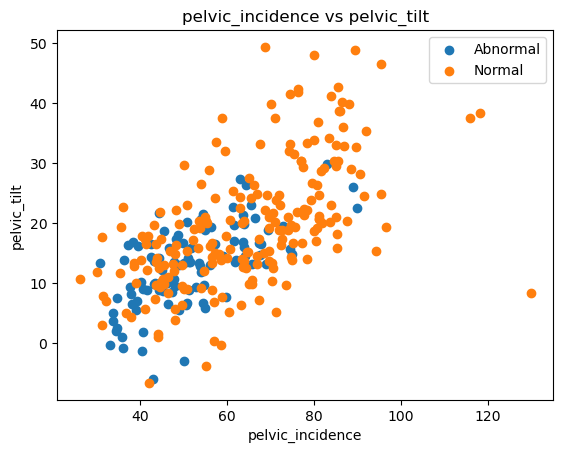

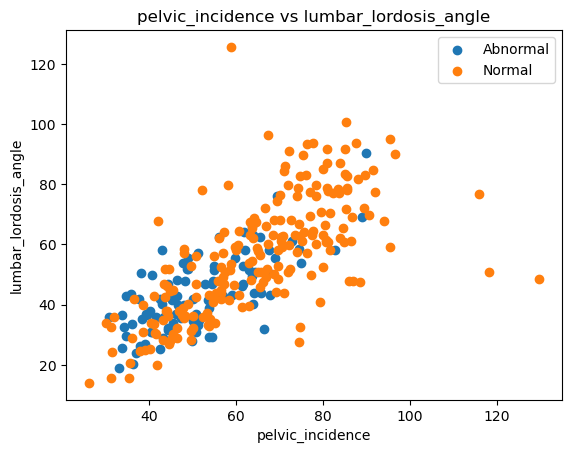

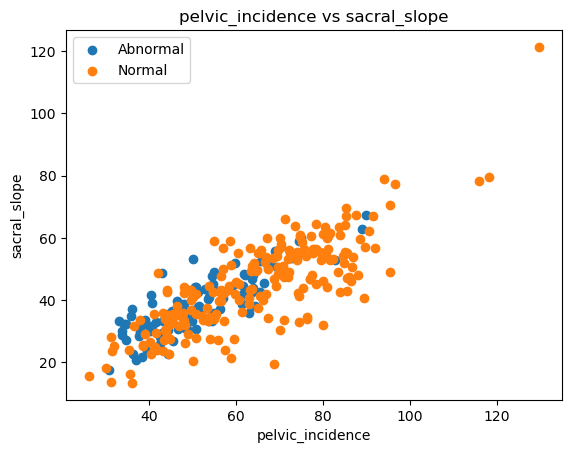

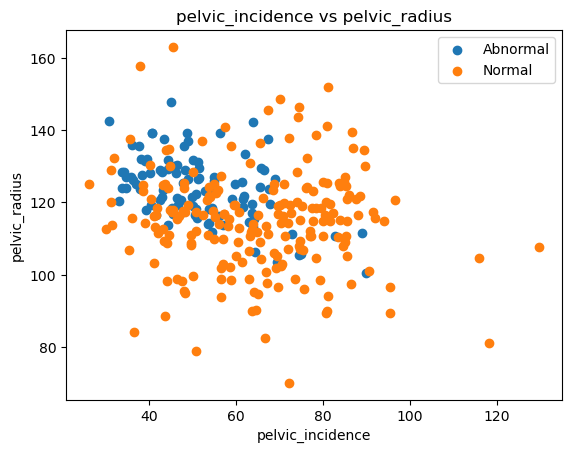

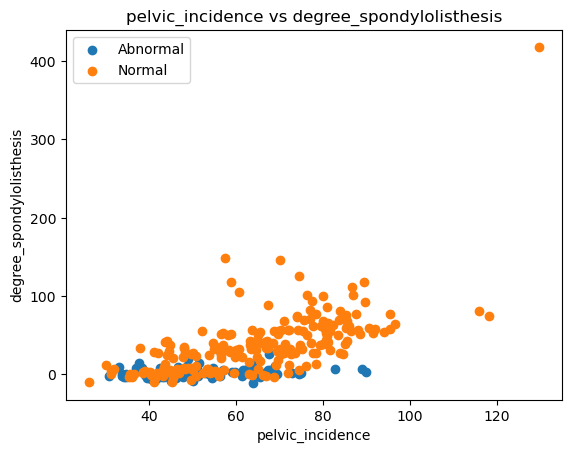

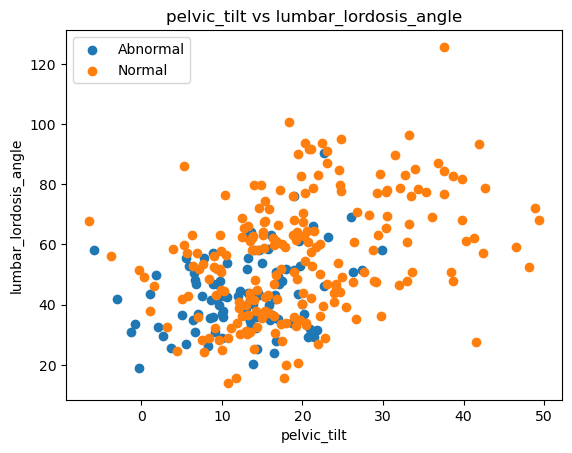

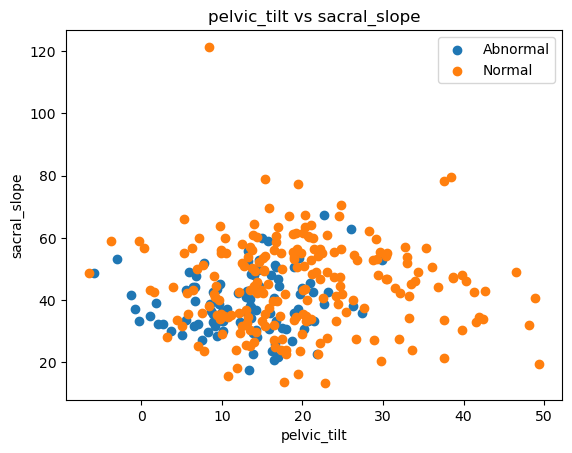

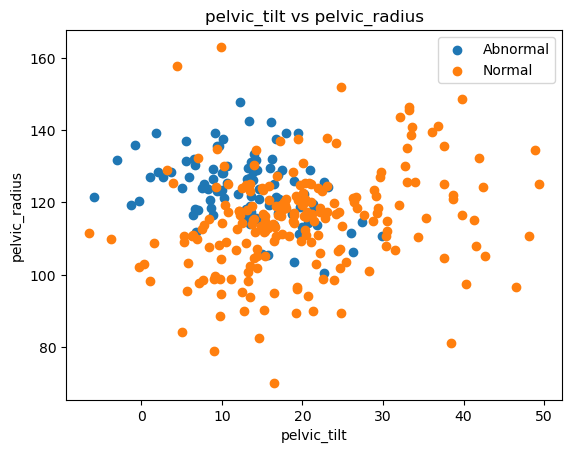

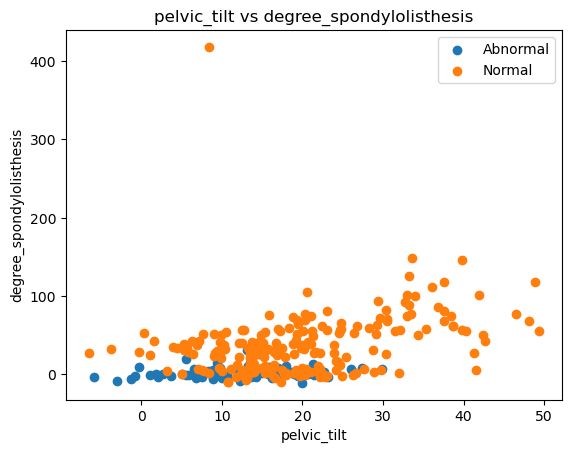

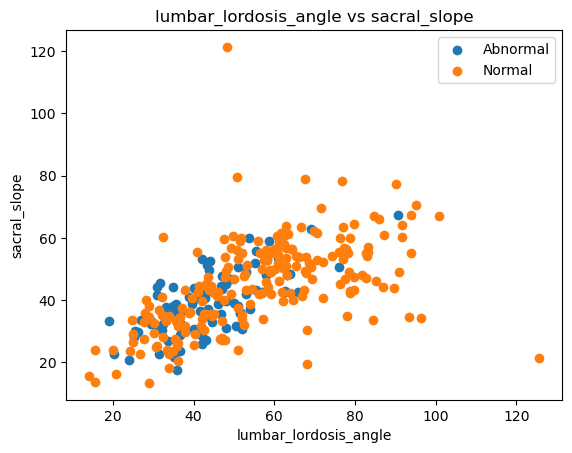

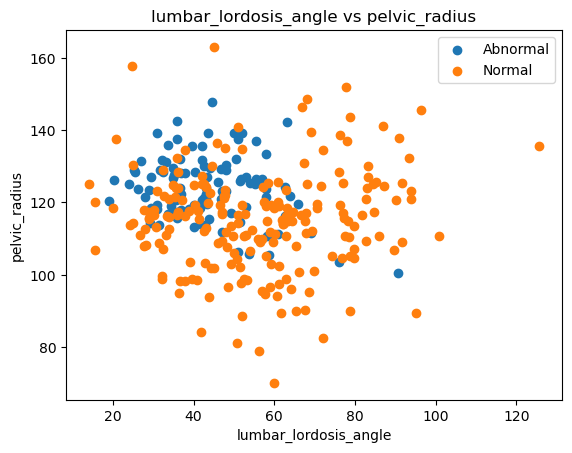

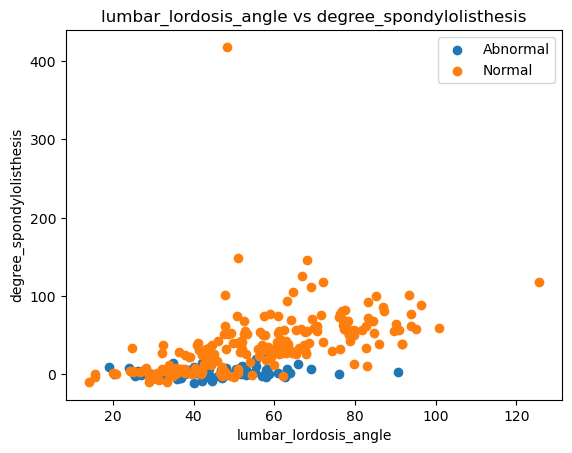

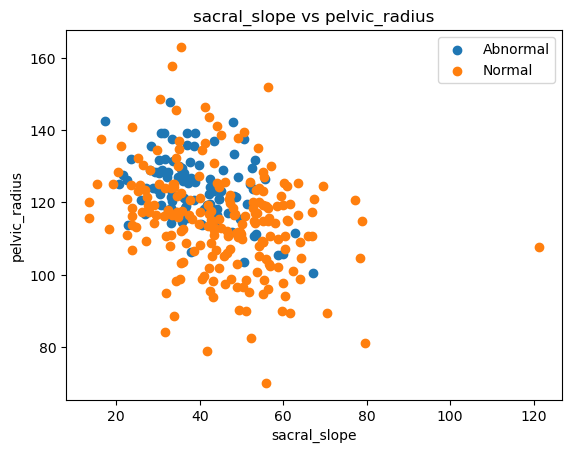

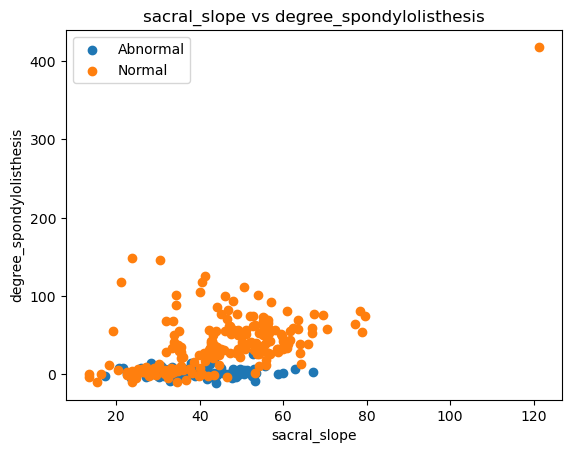

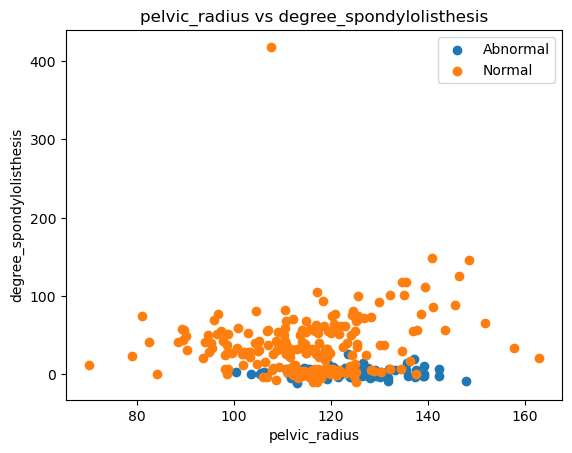

In [3]:
# 6*5/2
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        plt.figure()

        plt.scatter(
            weka_2c[weka_2c[target] == 0][features[i]],
            weka_2c[weka_2c[target] == 0][features[j]],
            label="Abnormal",
            # alpha=0.7   # define the transparent value
        )

        plt.scatter(
            weka_2c[weka_2c[target] == 1][features[i]],
            weka_2c[weka_2c[target] == 1][features[j]],
            label="Normal",
            # alpha=0.7   
        )

        plt.xlabel(features[i])
        plt.ylabel(features[j])
        plt.title(f"{features[i]} vs {features[j]}")
        plt.legend()
        plt.show()

#### ii. Boxplots

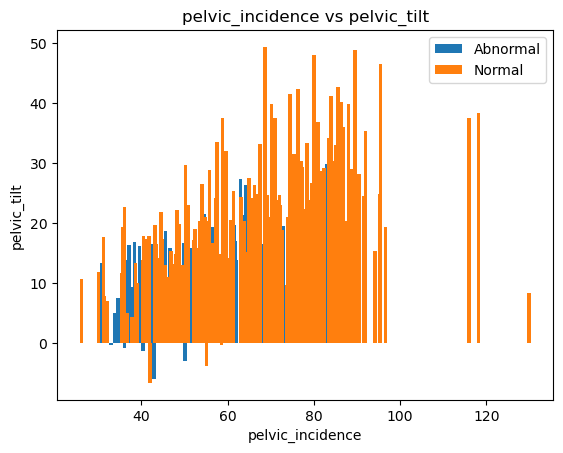

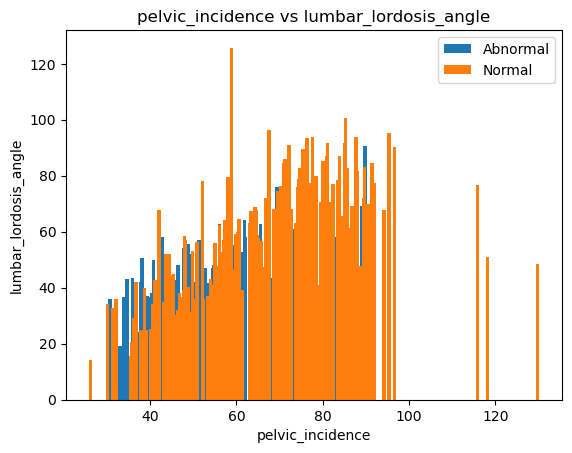

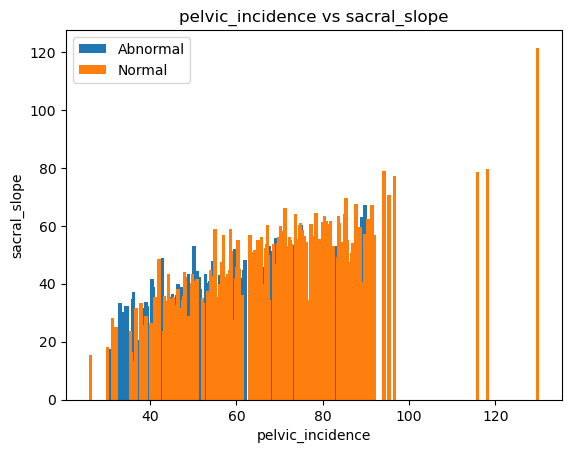

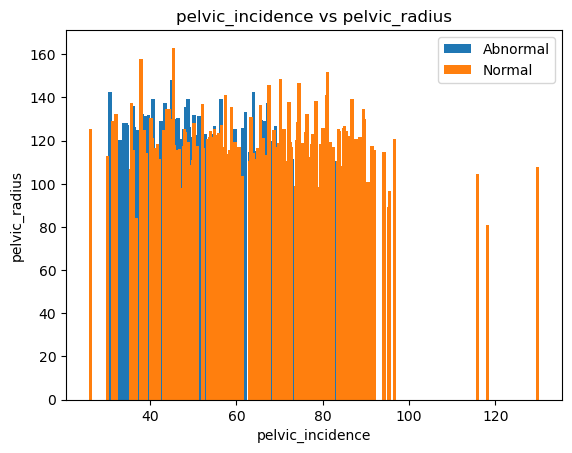

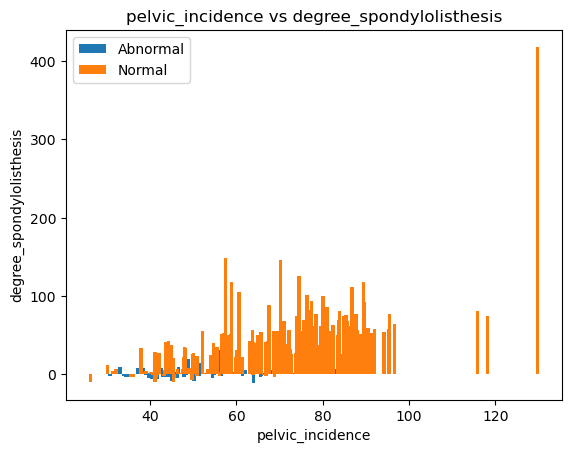

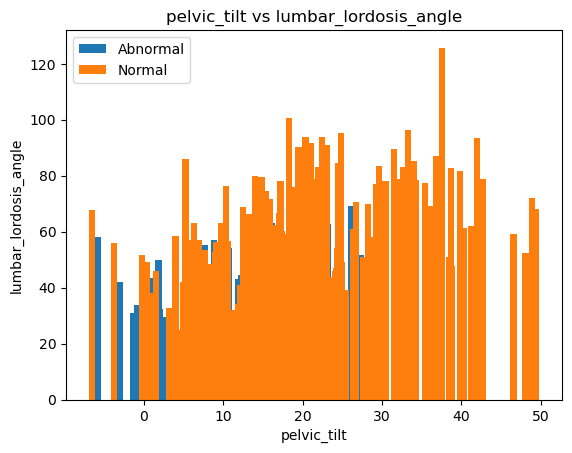

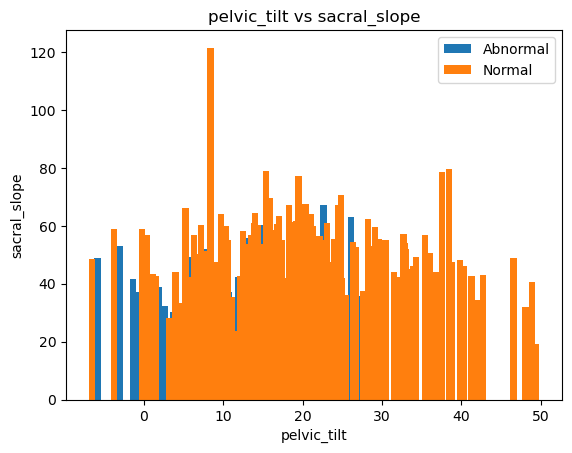

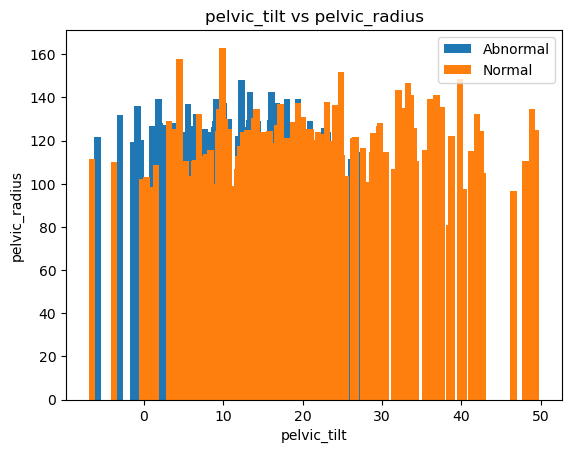

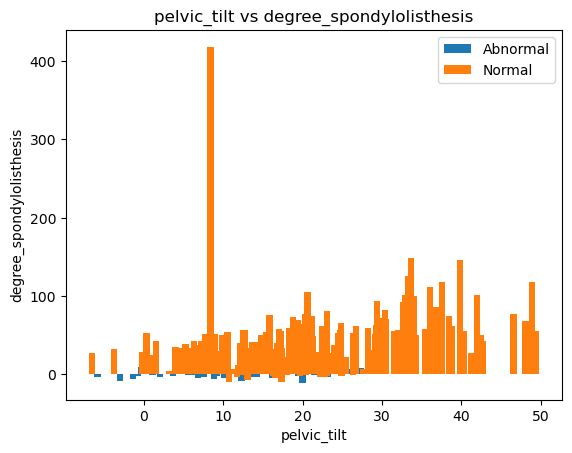

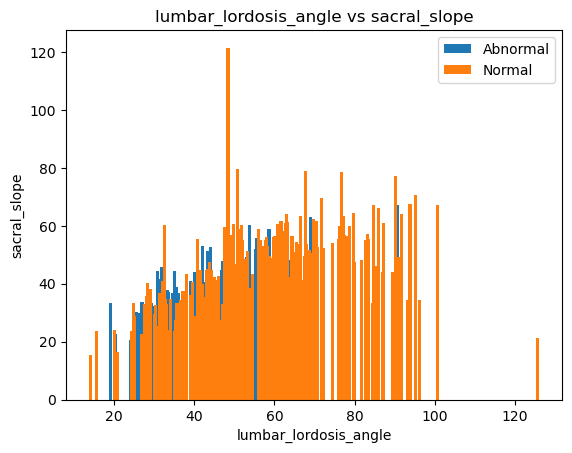

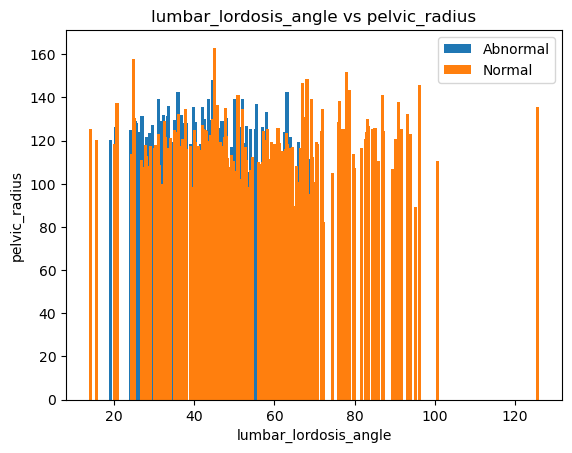

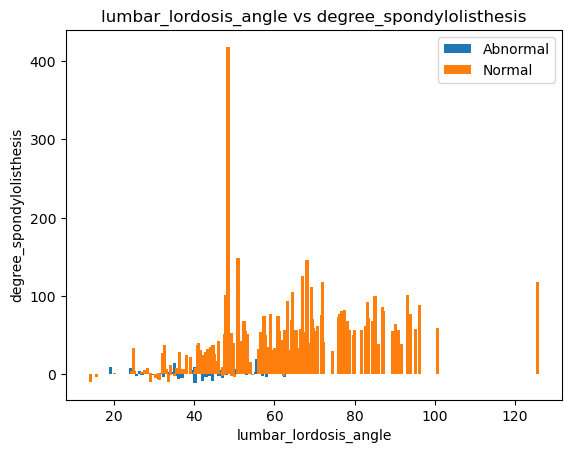

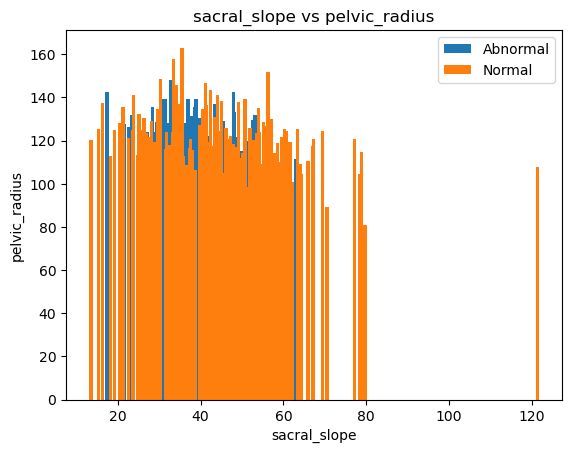

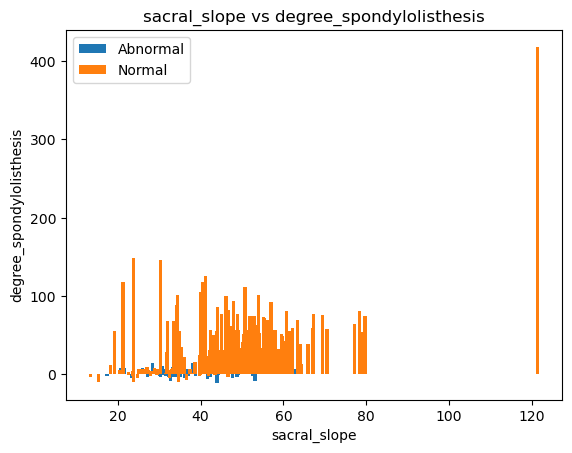

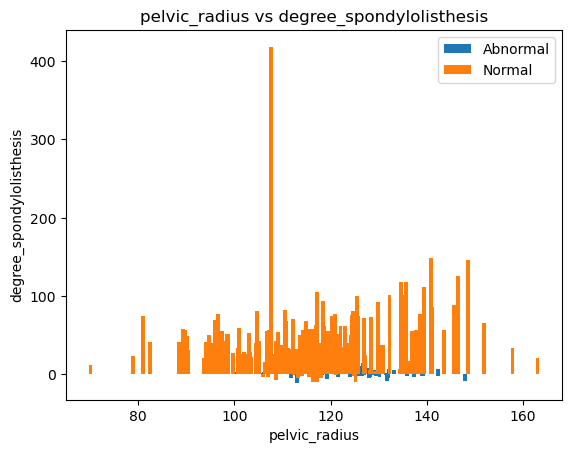

In [4]:
# 6*5/2
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        plt.figure()

        plt.bar(
            weka_2c[weka_2c[target] == 0][features[i]],
            weka_2c[weka_2c[target] == 0][features[j]],
            label="Abnormal",
            # alpha=0.7   # define the transparent value
        )

        plt.bar(
            weka_2c[weka_2c[target] == 1][features[i]],
            weka_2c[weka_2c[target] == 1][features[j]],
            label="Normal",
            # alpha=0.7   
        )

        plt.xlabel(features[i])
        plt.ylabel(features[j])
        plt.title(f"{features[i]} vs {features[j]}")
        plt.legend()
        plt.show()

#### iii. Split Data Set

In [5]:
#calculate split 
class_0_count = weka_2c[weka_2c[target]==0]['pelvic_incidence'].count()
class_1_count = weka_2c[weka_2c[target]==1]['pelvic_incidence'].count()

seg_class_0_train = weka_2c[weka_2c[target]==0][0:70]
seg_class_1_train = weka_2c[weka_2c[target]==1][0:140]
seg_class_0_test = weka_2c[weka_2c[target]==0][70:class_0_count]
seg_class_1_test = weka_2c[weka_2c[target]==1][140:class_1_count]


weka_2c_train = pd.concat([seg_class_0_train, seg_class_1_train])
weka_2c_test = pd.concat([seg_class_0_test, seg_class_1_test])


### (c) Classification

#### i. Euclidean Metric

In [215]:
weka_2c_train

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
210,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,0
211,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,0
212,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,0
213,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,0
214,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,0
...,...,...,...,...,...,...,...
135,77.121344,30.349874,77.481083,46.771470,110.611148,82.093607,1
136,88.024499,39.844669,81.774473,48.179830,116.601538,56.766083,1
137,83.396606,34.310989,78.423293,49.085617,110.466516,49.672096,1
138,72.054034,24.700737,79.874016,47.353297,107.172358,56.426159,1


In [6]:
import numpy as np
from scipy.spatial.distance import mahalanobis
# rememeber to use numpy to  take value only
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X.to_numpy()
        self.y_train = y.to_numpy().ravel()

    def weighted_vote(self, k_indices, distances):
        label_weights = {}
    
        for idx in k_indices:
            label = self.y_train[idx]
            weight = 1 / (distances[idx] + 1e-8) # 1e-8 to prevent the zero
    
            if label in label_weights:
                label_weights[label] += weight
            else:
                label_weights[label] = weight
    
        return max(label_weights, key=label_weights.get)


        
    def Euclidean_Metric(self,x_features,train_features):
        square_sum=0
        for x,x_train in zip(x_features,train_features):
            square_sum+=(float(x)-float(x_train))**2
        
        return np.sqrt(square_sum)

    def predict(self, X,select):
        X = X.to_numpy()
        predictions = []
        for x in X:
            predictions.append(self._predict_single(x,select))
        return np.array(predictions)

    def _predict_single(self, x , select):
        # Compute distances to all training points
        distances = [
            self.Euclidean_Metric(x, x_train)
            for x_train in self.X_train
        ]

        # Get indices of k nearest neighbors (sort with number of )
        k_indices = np.argsort(distances)[:self.k]


        if select == "normal":
            k_nearest_labels = self.y_train[k_indices]
    
            # Majority vote
            values, counts = np.unique(k_nearest_labels, return_counts=True)
    
            return values[np.argmax(counts)]  # argmax get the indices of the majority 
        elif select == "weighted":
            return self.weighted_vote(k_indices, distances)
        

    def minkowski_distance(self,x_features, train_features, p):
        p_sum=0

        
        if p != 00:
            for x,x_train in zip(x_features,train_features):
                p_sum+=abs(float(x)-float(x_train))**p
            return (p_sum)**(1/p)
        else:
            Chebyshev_sets=[]
            for x,x_train in zip(x_features,train_features):
                Chebyshev_sets.append(abs(float(x)-float(x_train)))

            return max(Chebyshev_sets)
                
        
    def minkowski_distance_predict(self, X, p, select):
        X = X.to_numpy()
        predictions = []
        for x in X:
            predictions.append(self._predict_single_minkowski_distance(x,p,select))
        return np.array(predictions)
    
    def _predict_single_minkowski_distance(self, x, p, select):
        # Compute distances to all training points
        distances = [
            self.minkowski_distance(x, x_train,p)
            for x_train in self.X_train
        ]

        # Get indices of k nearest neighbors (sort with number of )
        # print(f"distance : {distances}")
        k_indices = np.argsort(distances)[:self.k]

        if select == "normal":

            # Get labels of k nearest neighbors
            k_nearest_labels = self.y_train[k_indices]
            # print(f"k_nearest_labels : {k_nearest_labels}")
            # Majority vote
            values, counts = np.unique(k_nearest_labels, return_counts=True)
            return values[np.argmax(counts)]  # argmax get the indices of the majority 
        elif select == "weighted":
            return self.weighted_vote(k_indices, distances)
        
    def Mahalanobis_distance_predict(self, X, select):
        X = X.to_numpy()
        predictions = []
        for x in X:
            predictions.append(self._predict_single_mahalanobis_distance(x,select))
        return np.array(predictions)
    
    def _predict_single_mahalanobis_distance(self, x,select):
        # Compute distances to all training points
        mu = self.X_train.mean(axis=0)
        cov = np.cov(self.X_train, rowvar=False)
        inv_cov = np.linalg.inv(cov)
        
        distances = [
            mahalanobis(x_train, mu,inv_cov)
            for x_train in self.X_train
        ]

        # Get indices of k nearest neighbors (sort with number of )
        k_indices = np.argsort(distances)[:self.k]

        # Get labels of k nearest neighbors
        if select == "normal":
            k_nearest_labels = self.y_train[k_indices]
    
            # Majority vote
            values, counts = np.unique(k_nearest_labels, return_counts=True)
    
            return values[np.argmax(counts)]  # argmax get the indices of the majority 
        elif select == "weighted":
            return self.weighted_vote(k_indices, distances)

        


    

#### ii. Test Data

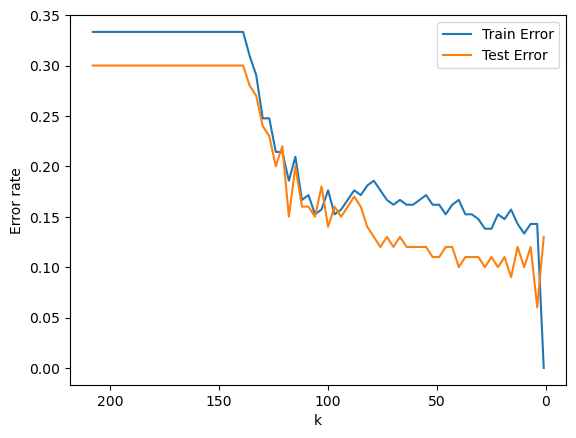

best K : 4
confusion matrix: TP:69/FN:1/TN:25/FP:5
true positive rate:0.9857142857142858
true negative rate:0.8333333333333334
precision:0.9324324324324325
F1-score:0.9583333333333333


In [7]:
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Example usage
features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis'
]

k_values = list(range(208, 0, -3))
train_errors = []
test_errors = []
X_train = weka_2c_train[features]
y_train = weka_2c_train[['class']]
X_test = weka_2c_test[features]
y_test = weka_2c_test[['class']]

for k_value in k_values:
    knn = KNN(k=k_value)
    knn.fit(X_train, y_train)
    
    y_train_pred = knn.predict(X_train,"normal")
    y_test_pred  = knn.predict(X_test,"normal")
    
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error  = 1 - accuracy_score(y_test, y_test_pred)

    train_errors.append(train_error)
    test_errors.append(test_error)


plt.figure()
plt.plot(k_values, train_errors, label='Train Error')
plt.plot(k_values, test_errors, label='Test Error')
plt.xlabel('k')
plt.ylabel('Error rate')
plt.legend()
plt.gca().invert_xaxis()  # the reverse matrix
plt.show()


best_index = np.argmin(test_errors)
k_target = k_values[best_index]
print(f"best K : {k_target}")
knn = KNN(k=k_target)
knn.fit(X_train, y_train)
y_test_pred  = knn.predict(X_test,"normal")
cm = confusion_matrix(y_test, y_test_pred) # confusion matrix
TN, FP, FN, TP = cm.ravel()
TPR = TP / (TP + FN)   # Recall / Sensitivity
TNR = TN / (TN + FP)   # Specificity
Precision = TP / (TP + FP) # Precision 
F1 = 2 * Precision * TPR / (Precision + TPR) # F1 Score


print(f"confusion matrix: TP:{TP}/FN:{FN}/TN:{TN}/FP:{FP}")
print(f"true positive rate:{TPR}")
print(f"true negative rate:{TNR}")
print(f"precision:{Precision}")
print(f"F1-score:{F1}")


#### iii. Learning Curve

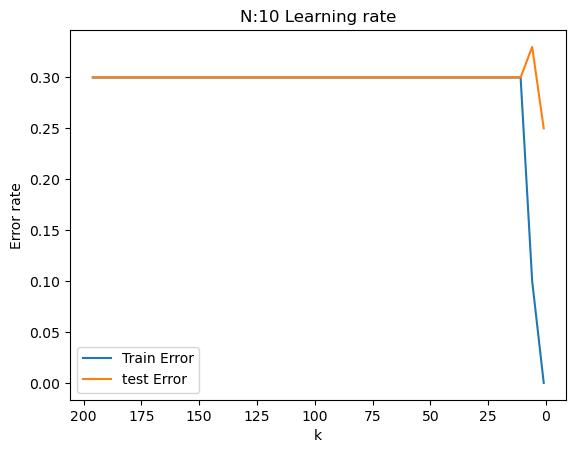

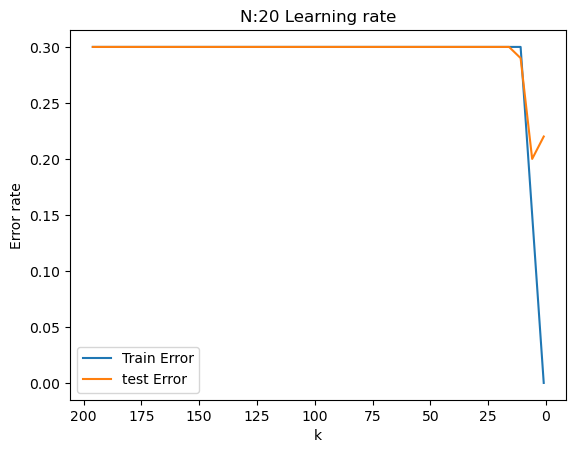

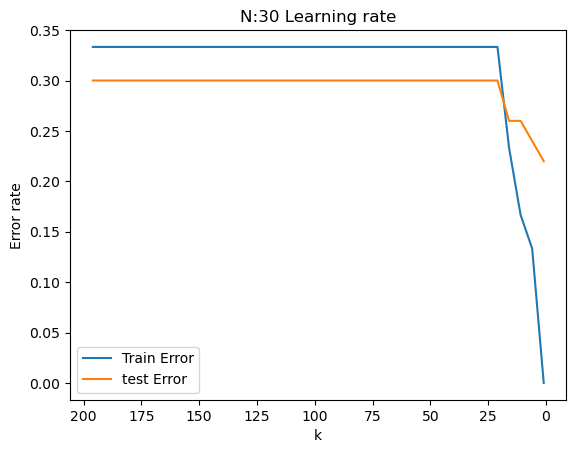

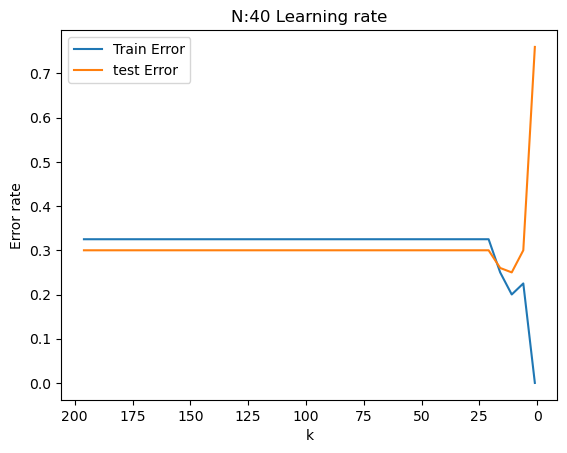

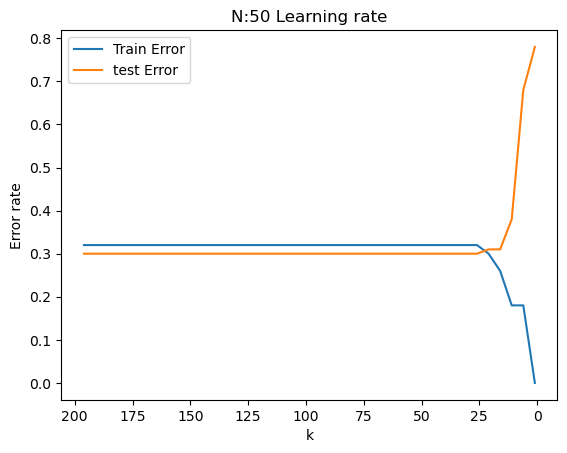

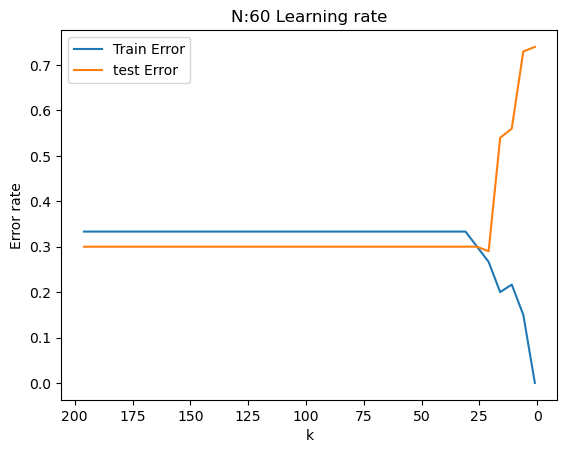

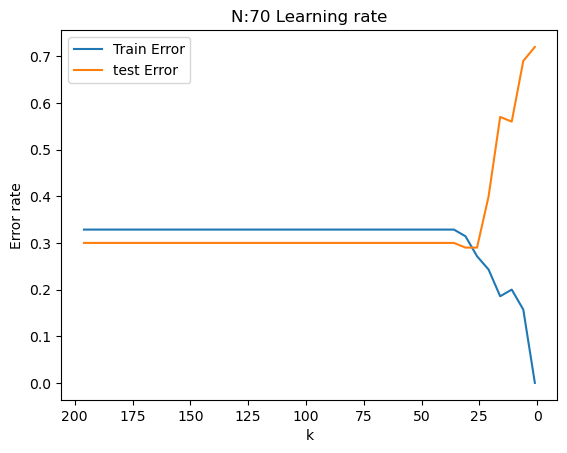

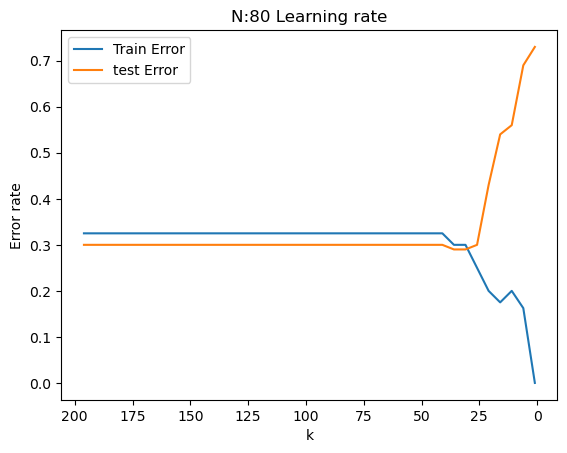

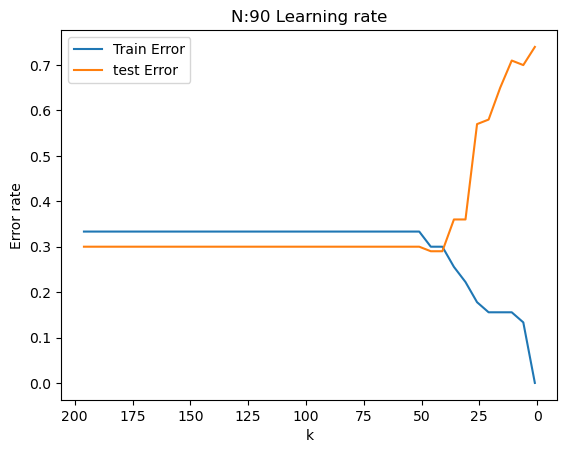

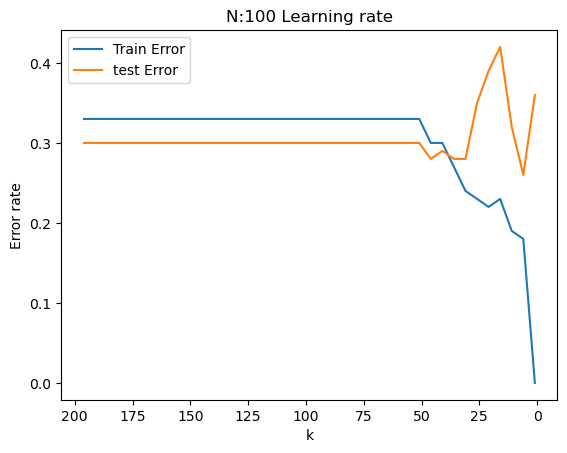

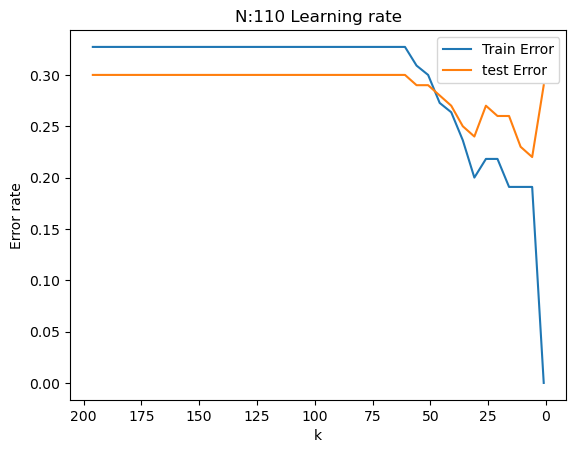

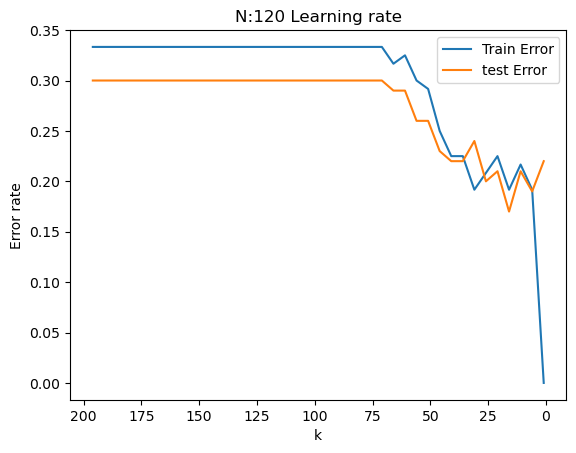

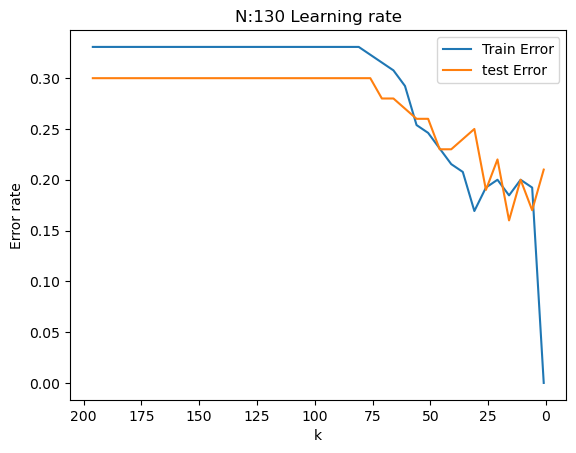

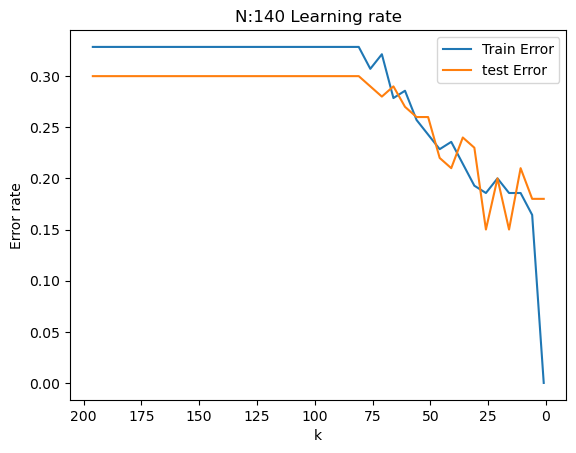

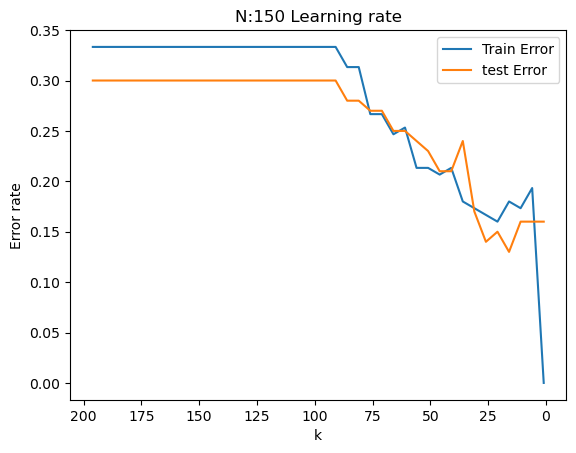

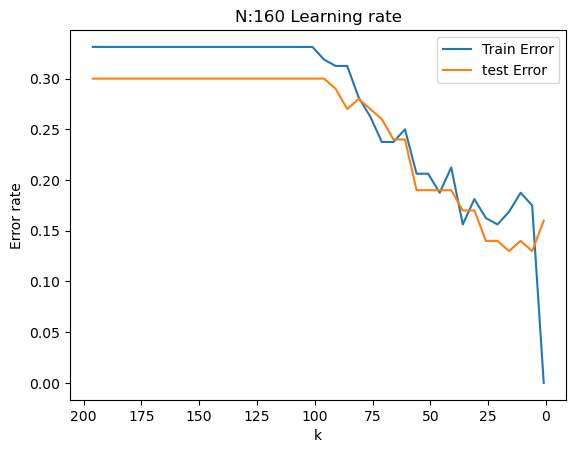

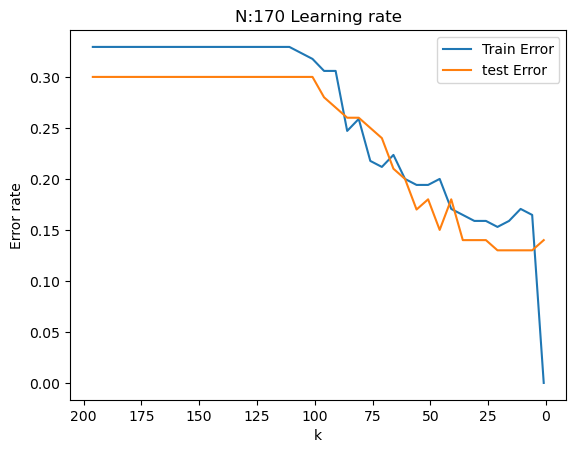

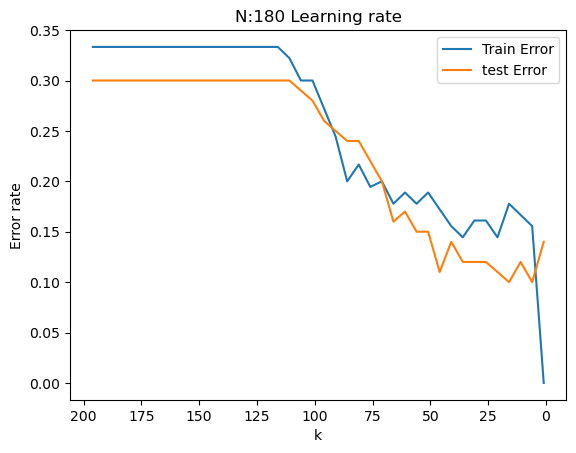

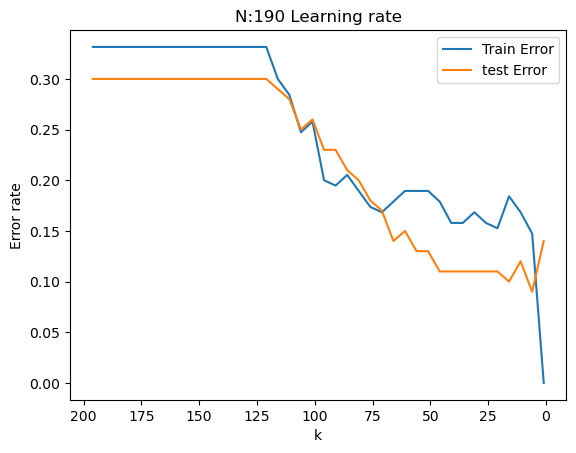

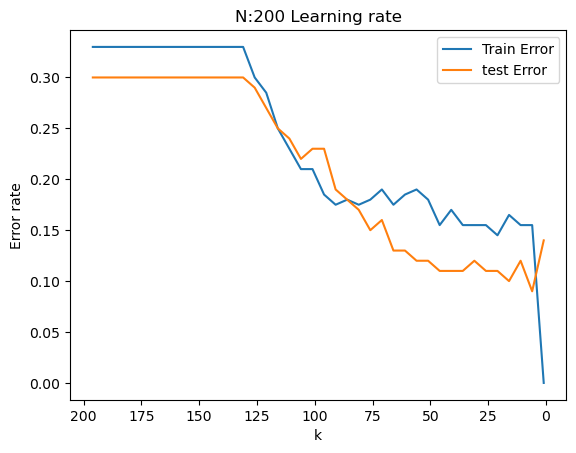

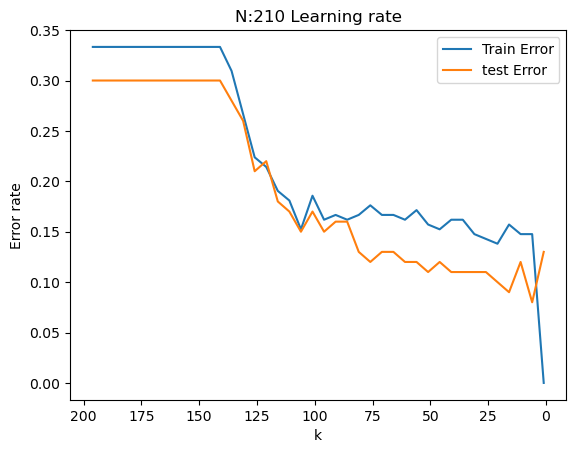

In [8]:
n_values = list(range(10,220,10))
k_values = list(range(1,201,5))

class_0_count = weka_2c[weka_2c[target]==0]['pelvic_incidence'].count()
class_1_count = weka_2c[weka_2c[target]==1]['pelvic_incidence'].count()
train_errors,test_errors=[],[]
features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis'
]


for n in n_values:

    #calculate split 
    class_0_n_select = n//3
    class_1_n_select = n - class_0_n_select
    
    seg_class_0_train = weka_2c[weka_2c[target]==0][0:class_0_n_select]
    seg_class_1_train = weka_2c[weka_2c[target]==1][0:class_1_n_select]
    
    weka_2c_train = pd.concat([seg_class_0_train, seg_class_1_train])
    X_train=weka_2c_train[features]
    y_train=weka_2c_train[['class']]
    X_test=weka_2c_test[features]
    y_test = weka_2c_test[['class']]

    for k in k_values:
        knn = KNN(k=k)
        knn.fit(X_train, y_train)
        y_train_pred = knn.predict(X_train,"normal")
        y_test_pred  = knn.predict(X_test,"normal")
        
        train_error = 1 - accuracy_score(y_train, y_train_pred)
        test_error  = 1 - accuracy_score(y_test, y_test_pred)
    
        train_errors.append(train_error)
        test_errors.append(test_error)
        
    plt.figure()
    plt.title(f"N:{n} Learning rate")
    plt.plot(k_values, train_errors, label='Train Error')
    plt.plot(k_values, test_errors, label='test Error')
    plt.xlabel('k')
    plt.ylabel('Error rate')
    plt.legend()
    plt.gca().invert_xaxis()  # reverse
    plt.show()

    train_errors,test_errors=[],[]
        
    
    

### (d) Other Metrics

#### i. Minkowski Distance.

##### A. Manhattan Distance with p = 1.

In [13]:
k_values = list(range(1,201,5))

train_errors,test_errors=[],[]
features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis'
]
p=1
X_train=weka_2c_train[features]
y_train=weka_2c_train[['class']]
X_test=weka_2c_test[features]
y_test = weka_2c_test[['class']]

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_train_pred = knn.minkowski_distance_predict(X_train,p,"normal")
    y_test_pred  = knn.minkowski_distance_predict(X_test,p,"normal")
    
    test_error  = 1 - accuracy_score(y_test, y_test_pred)
    test_errors.append(test_error)
    

target_index = np.argmin(test_errors)
k_target = k_values[target_index]
    
overall_k_table = pd.DataFrame({
    'k': k_values,
    'test_error': test_errors
})

print(f"The perfect k : {k_target}")
overall_k_table

The perfect k : 1


,k,test_error
0,1,0.11
1,6,0.11
2,11,0.11
3,16,0.12
4,21,0.12
5,26,0.11
6,31,0.12
7,36,0.13
8,41,0.13
9,46,0.13


##### B. With log10(p) in {0.1, 0.2, 0.3, ... ,1}.

In [14]:
log10_p_values = np.round(np.arange(0.1, 1.0 + 1e-9, 0.1), 10)

train_errors,test_errors=[],[]
features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis'
]

X_train=weka_2c_train[features]
y_train=weka_2c_train[['class']]
X_test=weka_2c_test[features]
y_test = weka_2c_test[['class']]

for p in log10_p_values:
    knn = KNN(k=k_target)
    knn.fit(X_train, y_train)
    y_train_pred = knn.minkowski_distance_predict(X_train,p,"normal")
    y_test_pred  = knn.minkowski_distance_predict(X_test,p,"normal")
    
    test_error  = 1 - accuracy_score(y_test, y_test_pred)
    test_errors.append(test_error)
    

target_index = np.argmin(test_errors)
p_target = log10_p_values[target_index]
    
overall_p_table = pd.DataFrame({
    'p': log10_p_values,
    'test_error': test_errors
})
overall_p_table

,p,test_error
0,0.1,0.24
1,0.2,0.22
2,0.3,0.18
3,0.4,0.16
4,0.5,0.15
5,0.6,0.15
6,0.7,0.15
7,0.8,0.13
8,0.9,0.11
9,1.0,0.11


##### C. Chebyshev Distance With p -> infinity.

In [15]:
k_values = list(range(1,201,5))

train_errors,test_errors=[],[]
features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis'
]
p=00
X_train=weka_2c_train[features]
y_train=weka_2c_train[['class']]
X_test=weka_2c_test[features]
y_test = weka_2c_test[['class']]

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_train_pred = knn.minkowski_distance_predict(X_train,p,"normal")
    y_test_pred  = knn.minkowski_distance_predict(X_test,p,"normal")
    
    test_error  = 1 - accuracy_score(y_test, y_test_pred)
    test_errors.append(test_error)
    

target_index = np.argmin(test_errors)
k_target = k_values[target_index]
    
overall_k_table = pd.DataFrame({
    'k': k_values,
    'test_error': test_errors
})

print(f"The perfect k : {k_target}")
overall_k_table

The perfect k : 16


,k,test_error
0,1,0.13
1,6,0.09
2,11,0.12
3,16,0.08
4,21,0.11
5,26,0.12
6,31,0.12
7,36,0.10
8,41,0.13
9,46,0.12


#### ii. Mahalanobis Distance.

In [25]:
k_values = list(range(1,201,5))

train_errors,test_errors=[],[]
features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis'
]
X_train=weka_2c_train[features]
y_train=weka_2c_train[['class']]
X_test=weka_2c_test[features]
y_test = weka_2c_test[['class']]

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_train_pred = knn.Mahalanobis_distance_predict(X_train,'normal')
    y_test_pred  = knn.Mahalanobis_distance_predict(X_test,'normal')
    
    test_error  = 1 - accuracy_score(y_test, y_test_pred)
    test_errors.append(test_error)
    

target_index = np.argmin(test_errors)
k_target = k_values[target_index]
    
overall_M_table = pd.DataFrame({
    'k': k_values,
    'test_error': test_errors
})


### (e) Weighted Decision

In [26]:
Euclidean_test_errors,Manhattan_test_errors,Chebyshev_test_errors=[],[],[]

features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis'
]

X_train=weka_2c_train[features]
y_train=weka_2c_train[['class']]
X_test=weka_2c_test[features]
y_test = weka_2c_test[['class']]



for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_test_pred  = knn.predict(X_test,"weighted")
    
    test_error  = 1 - accuracy_score(y_test, y_test_pred)
    Euclidean_test_errors.append(test_error)
    
    y_test_pred  = knn.minkowski_distance_predict(X_test,0.8,"weighted")
    
    test_error  = 1 - accuracy_score(y_test, y_test_pred)
    Manhattan_test_errors.append(test_error)
    
    y_test_pred  = knn.minkowski_distance_predict(X_test,00,"weighted")
    
    test_error  = 1 - accuracy_score(y_test, y_test_pred)
    Chebyshev_test_errors.append(test_error)
    

Euclidean_target_index = np.argmin(Euclidean_test_errors)
Manhattan_target_index = np.argmin(Manhattan_test_errors)
Chebyshev_target_index = np.argmin(Chebyshev_test_errors)
Euclidean_k_target = k_values[Euclidean_target_index]
Manhattan_k_target = k_values[Manhattan_target_index]
Chebyshev_k_target = k_values[Chebyshev_target_index]
    
overall_table = pd.DataFrame({
    'k': k_values,
    'Euclidean_test_errors': Euclidean_test_errors,
    'Manhattan_test_errors': Manhattan_test_errors,
    'Chebyshev_test_errors': Chebyshev_test_errors
})
print(f"Euclidean_k_target:{Euclidean_k_target} / Manhattan_k_target:{Manhattan_k_target} / Chebyshev_k_target:{Chebyshev_k_target} ")
overall_table

Euclidean_k_target:6 / Manhattan_k_target:6 / Chebyshev_k_target:16 


,k,Euclidean_test_errors,Manhattan_test_errors,Chebyshev_test_errors
0,1,0.13,0.13,0.13
1,6,0.10,0.10,0.13
2,11,0.12,0.11,0.12
3,16,0.11,0.11,0.11
4,21,0.11,0.10,0.12
5,26,0.11,0.10,0.12
6,31,0.11,0.11,0.11
7,36,0.11,0.12,0.11
8,41,0.11,0.12,0.11
9,46,0.11,0.13,0.12


### (f) Training Error Rate

In [ ]:
# 
0.10

In [27]:
Euclidean_train_errors,Manhattan_train_errors,Chebyshev_train_errors=[],[],[]
log10_p_values = np.round(np.arange(0.1, 1.0 + 1e-9, 0.1), 10)

features = [
    'pelvic_incidence',
    'pelvic_tilt',
    'lumbar_lordosis_angle',
    'sacral_slope',
    'pelvic_radius',
    'degree_spondylolisthesis'
]

X_train=weka_2c_train[features]
y_train=weka_2c_train[['class']]
X_test=weka_2c_test[features]
y_test = weka_2c_test[['class']]



for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_train_pred  = knn.predict(X_train,"weighted")
    
    train_error  = 1 - accuracy_score(y_train, y_train_pred)
    Euclidean_train_errors.append(train_error)
    
    y_train_pred  = knn.minkowski_distance_predict(X_train,0.8,"weighted")
    
    train_error  = 1 - accuracy_score(y_train, y_train_pred)
    Manhattan_train_errors.append(train_error)
    
    y_train_pred  = knn.minkowski_distance_predict(X_train,00,"weighted")
    
    train_error  = 1 - accuracy_score(y_train, y_train_pred)
    Chebyshev_train_errors.append(train_error)
    

Euclidean_target_index = np.argmin(Euclidean_train_errors)
Manhattan_target_index = np.argmin(Manhattan_train_errors)
Chebyshev_target_index = np.argmin(Chebyshev_train_errors)
Euclidean_k_target = k_values[Euclidean_target_index]
Manhattan_k_target = k_values[Manhattan_target_index]
Chebyshev_k_target = k_values[Chebyshev_target_index]
    
overall_table = pd.DataFrame({
    'k': k_values,
    'Euclidean_train_errors': Euclidean_train_errors,
    'Manhattan_train_errors': Manhattan_train_errors,
    'Chebyshev_train_errors': Chebyshev_train_errors
})
print(f"Euclidean_k_target:{Euclidean_k_target} / Manhattan_k_target:{Manhattan_k_target} / Chebyshev_k_target:{Chebyshev_k_target} ")
overall_table

Euclidean_k_target:1 / Manhattan_k_target:1 / Chebyshev_k_target:1 


,k,Euclidean_train_errors,Manhattan_train_errors,Chebyshev_train_errors
0,1,0.0,0.0,0.0
1,6,0.0,0.0,0.0
2,11,0.0,0.0,0.0
3,16,0.0,0.0,0.0
4,21,0.0,0.0,0.0
5,26,0.0,0.0,0.0
6,31,0.0,0.0,0.0
7,36,0.0,0.0,0.0
8,41,0.0,0.0,0.0
9,46,0.0,0.0,0.0
